In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import os, json, zipfile
from datetime import datetime

print("✅ TensorFlow Version:", tf.__version__)
print("✅ All Libraries Imported!")
print("✅ GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)

✅ TensorFlow Version: 2.20.0
✅ All Libraries Imported!
✅ GPU Available: True


In [19]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',   'Coat',
               'Sandal',  'Shirt',   'Sneaker',  'Bag',     'Boot']

print(f"✅ Dataset Loaded!")
print(f"   Train Images : {X_train_raw.shape}")
print(f"   Test  Images : {X_test_raw.shape}")
print(f"   Image Size   : {X_train_raw.shape[1:]} (Grayscale)")
print(f"   Classes      : {len(class_names)}")
print(f"   Pixel Range  : {X_train_raw.min()} - {X_train_raw.max()}")
print(f"   Data Type    : {X_train_raw.dtype}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Dataset Loaded!
   Train Images : (60000, 28, 28)
   Test  Images : (10000, 28, 28)
   Image Size   : (28, 28) (Grayscale)
   Classes      : 10
   Pixel Range  : 0 - 255
   Data Type    : uint8


In [20]:
# --- 3.1 Missing Values ---
print("\n📌 Step 1: Missing Values Check...")
train_null = np.isnan(X_train_raw.astype(float)).sum()
test_null  = np.isnan(X_test_raw.astype(float)).sum()
print(f"   Train Missing : {train_null}")
print(f"   Test  Missing : {test_null}")


📌 Step 1: Missing Values Check...
   Train Missing : 0
   Test  Missing : 0


In [21]:
# --- 3.2 Corrupted Images (all black or all white) ---
print("\n📌 Step 2: Corrupted Images Check...")
def find_corrupted(images):
    return [i for i, img in enumerate(images) if img.max() == img.min()]

train_bad = find_corrupted(X_train_raw)
test_bad  = find_corrupted(X_test_raw)
print(f"   Train Corrupted : {len(train_bad)}")
print(f"   Test  Corrupted : {len(test_bad)}")


📌 Step 2: Corrupted Images Check...
   Train Corrupted : 0
   Test  Corrupted : 0


In [22]:
# --- 3.3 Duplicate Check (sample) ---
print("\n📌 Step 3: Duplicate Check (5000 samples)...")
sample    = X_train_raw[:5000].reshape(5000, -1)
unique_n  = len(np.unique(sample, axis=0))
print(f"   Duplicates Found : {5000 - unique_n}")


📌 Step 3: Duplicate Check (5000 samples)...
   Duplicates Found : 0


In [23]:
# --- 3.4 Label Validation ---
print("\n📌 Step 4: Label Validation...")
print(f"   Train Label Range : {y_train_raw.min()} → {y_train_raw.max()}")
print(f"   Test  Label Range : {y_test_raw.min()} → {y_test_raw.max()}")
print(f"   Expected          : 0 → {len(class_names)-1}")


📌 Step 4: Label Validation...
   Train Label Range : 0 → 9
   Test  Label Range : 0 → 9
   Expected          : 0 → 9


In [24]:
# --- 3.5 Shape Consistency ---
print("\n📌 Step 5: Shape Consistency...")
shapes = set(img.shape for img in X_train_raw[:200])
print(f"   Unique Shapes : {shapes}")
print(f"   Consistent    : {len(shapes) == 1}")


📌 Step 5: Shape Consistency...
   Unique Shapes : {(28, 28)}
   Consistent    : True


In [25]:
# --- 4.1 Normalize ---
print("\n📌 Step 1: Normalizing (0-255 → 0-1)...")
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0
print(f"   Before : {X_train_raw.min()} - {X_train_raw.max()}")
print(f"   After  : {X_train.min():.1f} - {X_train.max():.1f}")


📌 Step 1: Normalizing (0-255 → 0-1)...
   Before : 0 - 255
   After  : 0.0 - 1.0


In [26]:
# --- 4.2 Reshape for CNN (add channel dimension) ---
print("\n📌 Step 2: Reshaping for CNN input...")
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)
print(f"   New Shape : {X_train.shape}  (N, H, W, Channels)")


📌 Step 2: Reshaping for CNN input...
   New Shape : (60000, 28, 28, 1)  (N, H, W, Channels)


In [27]:
# --- 4.3 One-Hot Encode ---
print("\n📌 Step 3: One-Hot Encoding Labels...")
y_train_enc = to_categorical(y_train_raw, num_classes=10)
y_test_enc  = to_categorical(y_test_raw,  num_classes=10)
print(f"   Before : {y_train_raw.shape}")
print(f"   After  : {y_train_enc.shape}")


📌 Step 3: One-Hot Encoding Labels...
   Before : (60000,)
   After  : (60000, 10)


In [28]:
# --- 4.4 Train / Validation Split ---
print("\n📌 Step 4: Train/Validation Split (85/15)...")
X_train_f, X_val, y_train_f, y_val = train_test_split(
    X_train, y_train_enc,
    test_size=0.15, random_state=42,
    stratify=y_train_enc
)
print(f"   Train : {X_train_f.shape[0]}")
print(f"   Val   : {X_val.shape[0]}")
print(f"   Test  : {X_test.shape[0]}")


📌 Step 4: Train/Validation Split (85/15)...
   Train : 51000
   Val   : 9000
   Test  : 10000


In [29]:
# --- 4.5 Data Augmentation ---
print("\n📌 Step 5: Data Augmentation Setup...")
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
], name="augmentation")
print("   Flip | Rotation | Zoom  ✅")


📌 Step 5: Data Augmentation Setup...
   Flip | Rotation | Zoom  ✅


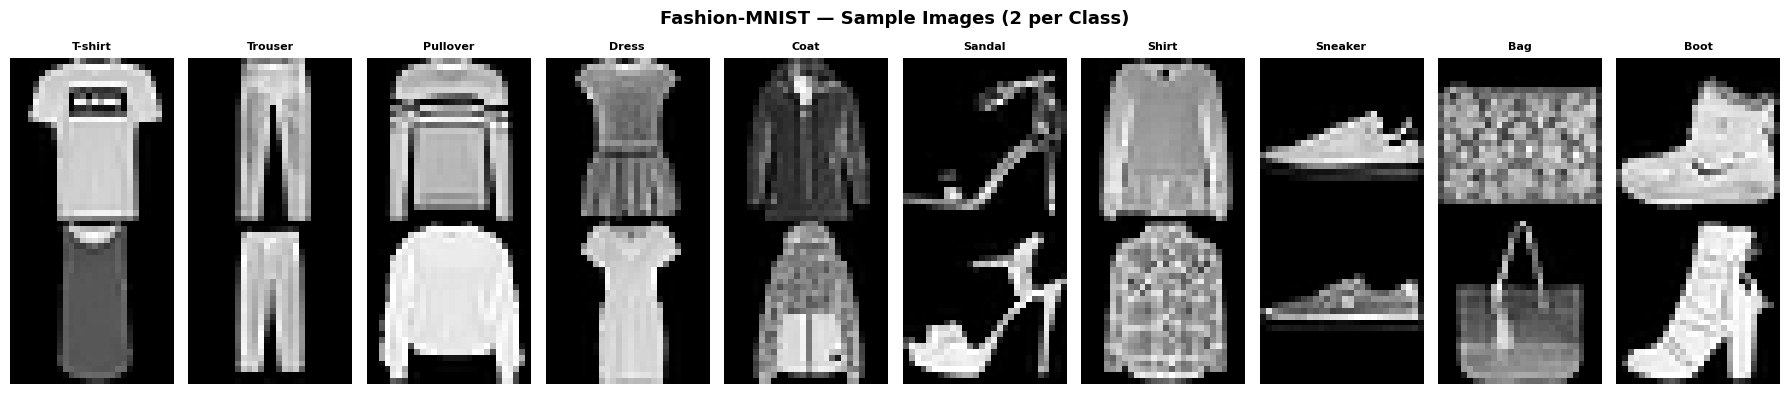

In [30]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Fashion-MNIST — Sample Images (2 per Class)',
             fontsize=13, fontweight='bold')

for col in range(10):
    for row in range(2):
        idx = np.where(y_train_raw == col)[0][row]
        axes[row][col].imshow(X_train_raw[idx], cmap='gray')
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(class_names[col], fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

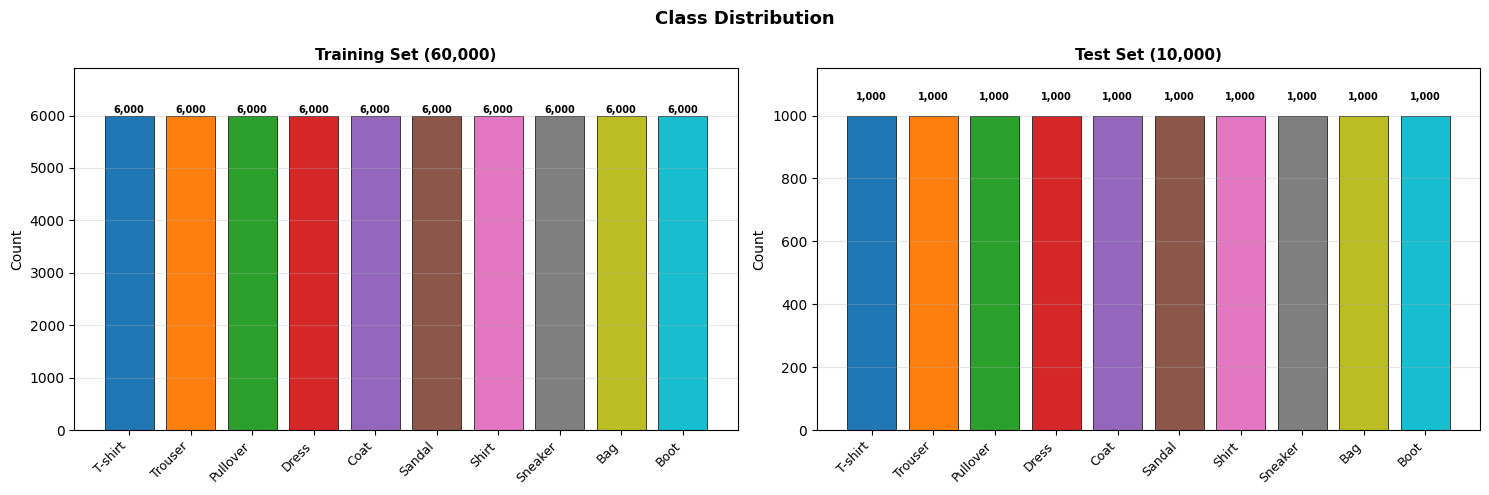

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Class Distribution', fontsize=13, fontweight='bold')
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for ax, (data, title) in zip(axes, [
    (y_train_raw, 'Training Set (60,000)'),
    (y_test_raw,  'Test Set (10,000)')
]):
    counts = [np.sum(data == i) for i in range(10)]
    bars = ax.bar(class_names, counts, color=colors,
                  edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50,
                f'{c:,}', ha='center', fontsize=7, fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

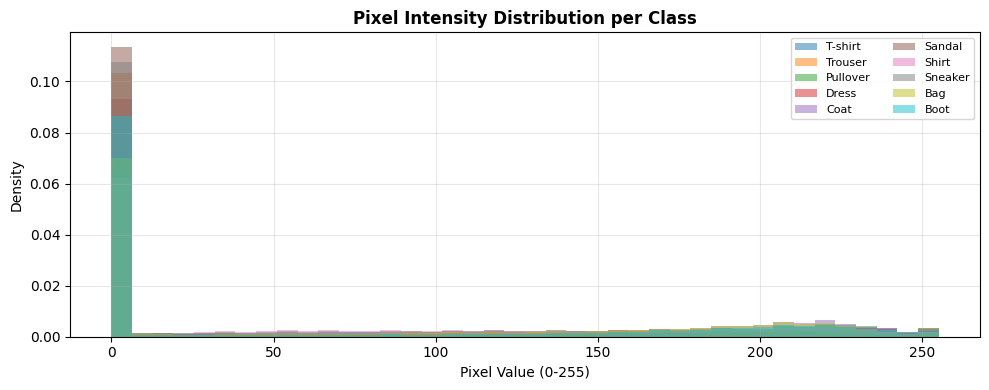

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))

colors_cls = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(10):
    class_pixels = X_train_raw[y_train_raw == i].flatten()
    ax.hist(class_pixels, bins=40, alpha=0.5,
            color=colors_cls[i], label=class_names[i], density=True)

ax.set_title('Pixel Intensity Distribution per Class', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Value (0-255)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.legend(ncol=2, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_pixel_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

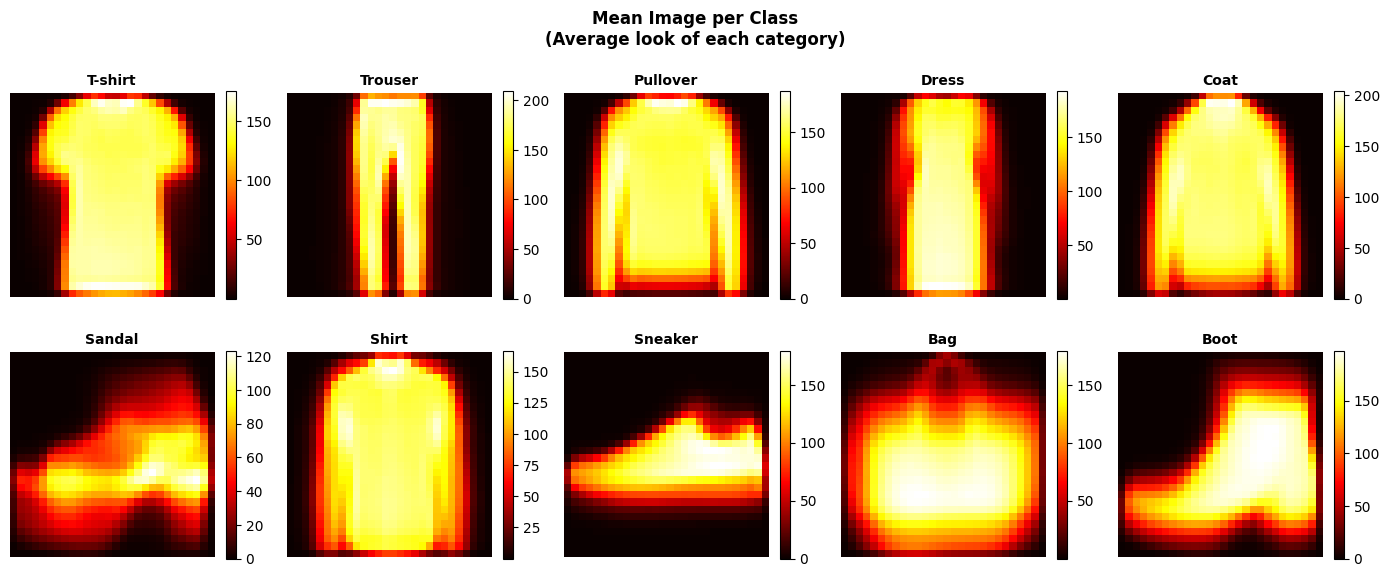

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Mean Image per Class\n(Average look of each category)',
             fontsize=12, fontweight='bold')
axes = axes.flatten()

for i in range(10):
    mean_img = X_train_raw[y_train_raw == i].mean(axis=0)
    im = axes[i].imshow(mean_img, cmap='hot')
    axes[i].set_title(class_names[i], fontsize=10, fontweight='bold')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.tight_layout()
plt.savefig('04_mean_images.png', dpi=120, bbox_inches='tight')
plt.show()

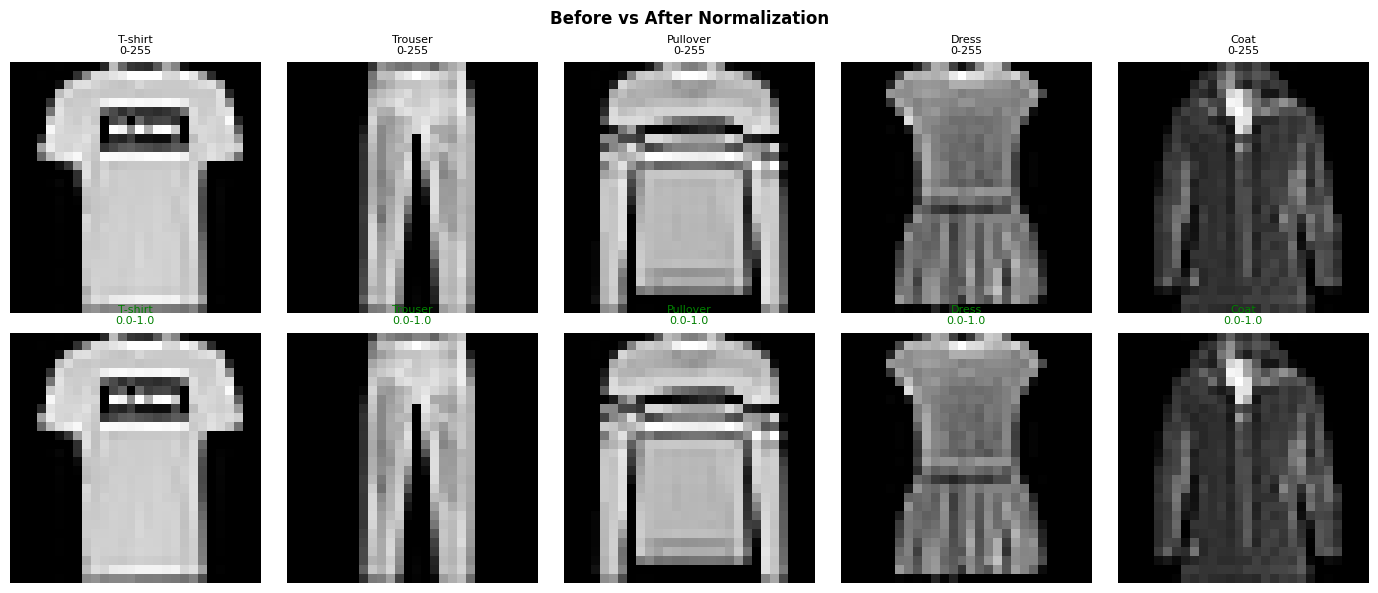

In [34]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Before vs After Normalization', fontsize=12, fontweight='bold')

for i in range(5):
    idx = np.where(y_train_raw == i)[0][0]
    axes[0][i].imshow(X_train_raw[idx], cmap='gray')
    axes[0][i].set_title(f'{class_names[i]}\n0-255', fontsize=8)
    axes[0][i].axis('off')

    axes[1][i].imshow(X_train.reshape(-1,28,28)[idx], cmap='gray')
    axes[1][i].set_title(f'{class_names[i]}\n0.0-1.0', fontsize=8, color='green')
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('05_normalization.png', dpi=120, bbox_inches='tight')
plt.show()

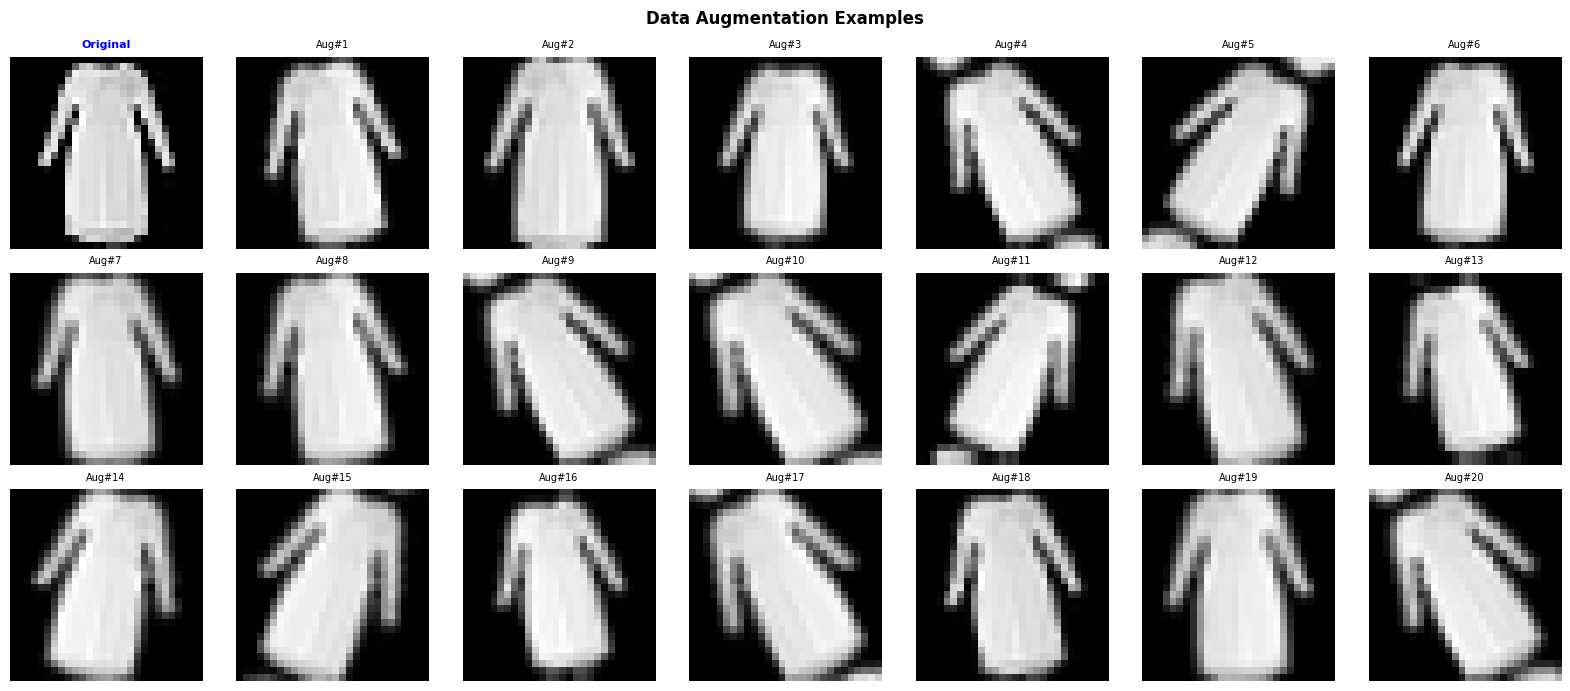

In [35]:
fig, axes = plt.subplots(3, 7, figsize=(16, 7))
fig.suptitle('Data Augmentation Examples', fontsize=12, fontweight='bold')

sample_img = X_train_f[0:1]

for row in range(3):
    for col in range(7):
        if row == 0 and col == 0:
            axes[row][col].imshow(X_train_f[0].reshape(28,28), cmap='gray')
            axes[row][col].set_title('Original', fontsize=8,
                                     color='blue', fontweight='bold')
        else:
            aug = data_augmentation(sample_img, training=True)[0]
            axes[row][col].imshow(aug.numpy().reshape(28,28), cmap='gray')
            axes[row][col].set_title(f'Aug#{row*7+col}', fontsize=7)
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('06_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [36]:
def build_model(input_shape=(28, 28, 1), num_classes=10):
    inputs = keras.Input(shape=input_shape)

    # Augmentation
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.35)(x)

    # Classifier
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.45)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='FashionMNIST_CNN')
    return model

model = build_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n✅ Model Built!")
print(f"   Total Parameters : {model.count_params():,}")

Model: "FashionMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             

 Total params: 438,890 (1.67 MB)

 Trainable params: 437,738 (1.67 MB)

 Non-trainable params: 1,152 (4.50 KB)


✅ Model Built!
   Total Parameters : 438,890


In [37]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1)
]

print("  Epochs     : 25 (EarlyStopping enabled)")
print("  Batch Size : 128")
print("  Optimizer  : Adam\n")

history = model.fit(
    X_train_f, y_train_f,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


  Epochs     : 25 (EarlyStopping enabled)
  Batch Size : 128
  Optimizer  : Adam

Epoch 1/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6146 - loss: 1.1585
Epoch 1: val_accuracy improved from None to 0.47878, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7041 - loss: 0.8358 - val_accuracy: 0.4788 - val_loss: 1.7891 - learning_rate: 0.0010
Epoch 2/25
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7874 - loss: 0.5756
Epoch 2: val_accuracy improved from 0.47878 to 0.85978, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.8005 - loss: 0.5428 - val_accuracy: 0.8598 - val_loss: 0.3853 - learning_rate: 0.0010
Epoch 3/25
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8239 - loss: 0.4752
Epoch 3: val_accuracy improved from 0.85978 to 0.86244, saving model to best_model.keras

Ep

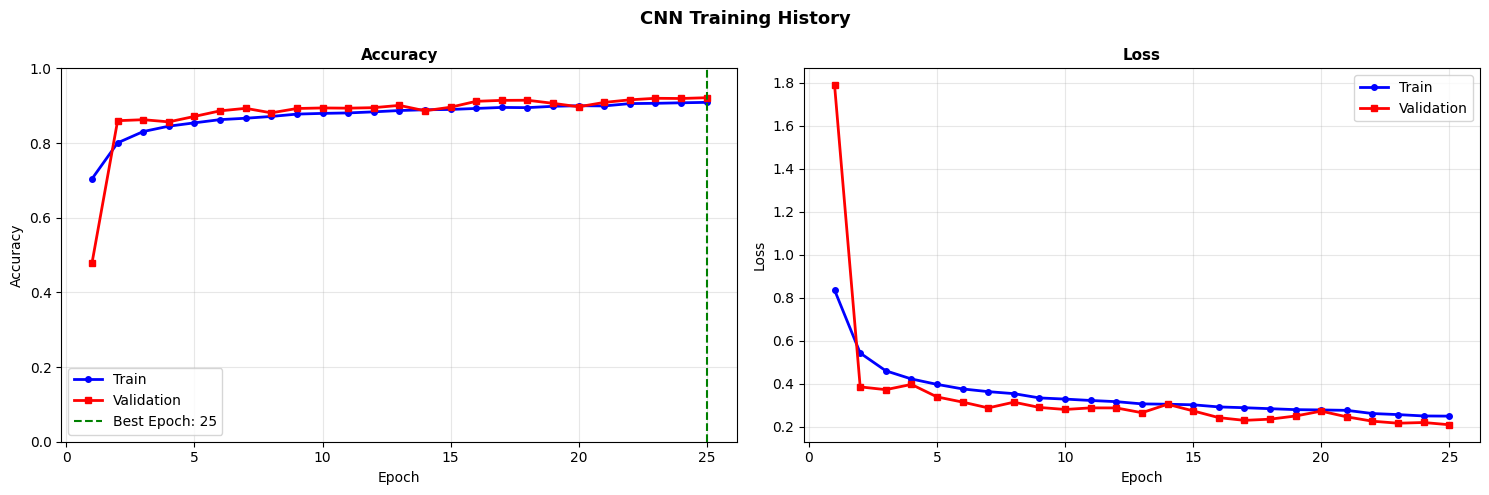

✅ Best Validation Accuracy : 92.13%  (Epoch 25)


In [38]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('CNN Training History', fontsize=13, fontweight='bold')

ep = range(1, len(history.history['accuracy']) + 1)
best_ep = history.history['val_accuracy'].index(
          max(history.history['val_accuracy'])) + 1

# Accuracy
axes[0].plot(ep, history.history['accuracy'],
             'b-o', lw=2, ms=4, label='Train')
axes[0].plot(ep, history.history['val_accuracy'],
             'r-s', lw=2, ms=4, label='Validation')
axes[0].axvline(best_ep, color='green', ls='--', lw=1.5,
                label=f'Best Epoch: {best_ep}')
axes[0].set_title('Accuracy', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

# Loss
axes[1].plot(ep, history.history['loss'],
             'b-o', lw=2, ms=4, label='Train')
axes[1].plot(ep, history.history['val_loss'],
             'r-s', lw=2, ms=4, label='Validation')
axes[1].set_title('Loss', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('07_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

best_val = max(history.history['val_accuracy'])
print(f"✅ Best Validation Accuracy : {best_val*100:.2f}%  (Epoch {best_ep})")

In [39]:
best_model = load_model('best_model.keras')

test_loss,  test_acc  = best_model.evaluate(X_test,    y_test_enc,  verbose=0)
val_loss,   val_acc   = best_model.evaluate(X_val,     y_val,       verbose=0)
train_loss, train_acc = best_model.evaluate(X_train_f, y_train_f,   verbose=0)

print(f"\n{'Metric':<18} {'Train':>8} {'Val':>8} {'Test':>8}")
print("=" * 45)
print(f"{'Accuracy':<18} {train_acc:>8.4f} {val_acc:>8.4f} {test_acc:>8.4f}")
print(f"{'Loss':<18} {train_loss:>8.4f} {val_loss:>8.4f} {test_loss:>8.4f}")
print("=" * 45)

y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test_raw.flatten()

print("\n📊 CLASSIFICATION REPORT\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Metric                Train      Val     Test
Accuracy             0.9303   0.9213   0.9170
Loss                 0.1861   0.2090   0.2247

📊 CLASSIFICATION REPORT

              precision    recall  f1-score   support

     T-shirt       0.89      0.85      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.91      0.86      0.89      1000
       Dress       0.90      0.93      0.91      1000
        Coat       0.85      0.90      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.77      0.76      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.99      0.98      0.98      1000
        Boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



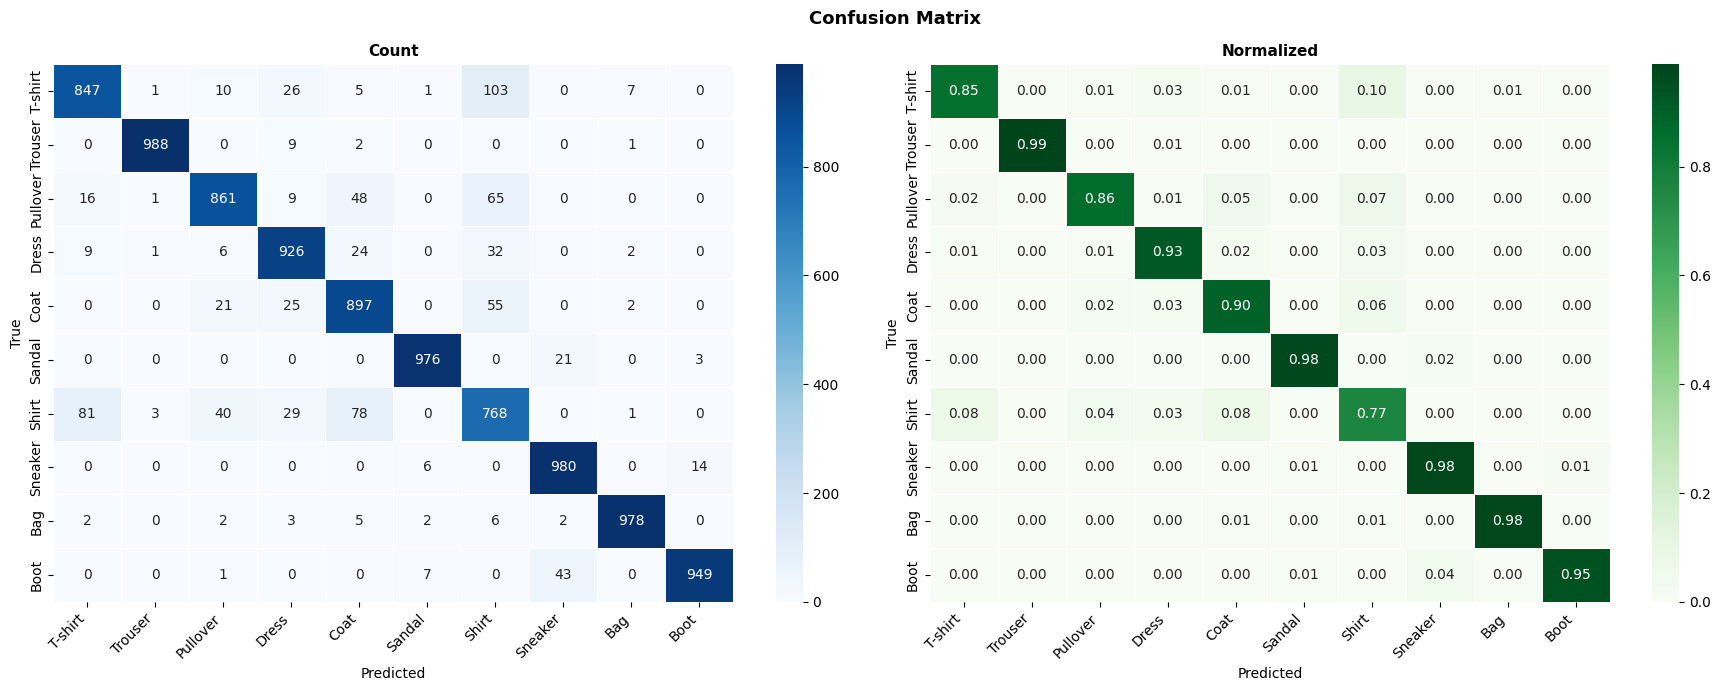

In [40]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.4)
axes[0].set_title('Count', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_xticklabels(class_names, rotation=45, ha='right')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.4)
axes[1].set_title('Normalized', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_xticklabels(class_names, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('08_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

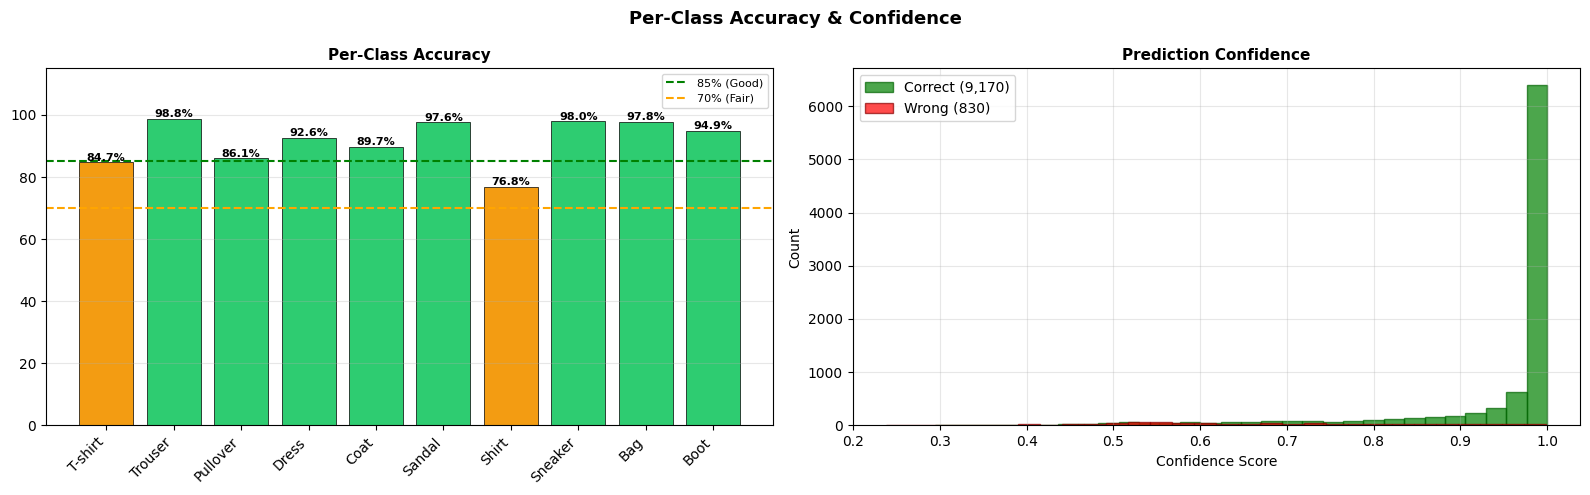


Per-Class Results:
  ⚠️ T-shirt     : 84.70%
  ✅ Trouser     : 98.80%
  ✅ Pullover    : 86.10%
  ✅ Dress       : 92.60%
  ✅ Coat        : 89.70%
  ✅ Sandal      : 97.60%
  ⚠️ Shirt       : 76.80%
  ✅ Sneaker     : 98.00%
  ✅ Bag         : 97.80%
  ✅ Boot        : 94.90%


In [41]:
per_class_acc  = cm.diagonal() / cm.sum(axis=1)
conf_scores    = np.max(y_pred_prob, axis=1)
correct_conf   = conf_scores[y_pred == y_true]
incorrect_conf = conf_scores[y_pred != y_true]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Class Accuracy & Confidence', fontsize=13, fontweight='bold')

# Per-Class Accuracy
bar_colors = ['#2ecc71' if a >= 0.85 else '#f39c12' if a >= 0.70
              else '#e74c3c' for a in per_class_acc]
bars = axes[0].bar(class_names, per_class_acc * 100,
                   color=bar_colors, edgecolor='black', lw=0.5)
for bar, acc in zip(bars, per_class_acc):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{acc*100:.1f}%', ha='center',
                 fontsize=8, fontweight='bold')
axes[0].axhline(85, color='green',  ls='--', lw=1.5, label='85% (Good)')
axes[0].axhline(70, color='orange', ls='--', lw=1.5, label='70% (Fair)')
axes[0].set_title('Per-Class Accuracy', fontsize=11, fontweight='bold')
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_ylim(0, 115); axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(fontsize=8)

# Confidence Distribution
axes[1].hist(correct_conf,   bins=30, alpha=0.7, color='green',
             label=f'Correct ({len(correct_conf):,})', edgecolor='darkgreen')
axes[1].hist(incorrect_conf, bins=30, alpha=0.7, color='red',
             label=f'Wrong ({len(incorrect_conf):,})', edgecolor='darkred')
axes[1].set_title('Prediction Confidence', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Confidence Score'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_accuracy_confidence.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nPer-Class Results:")
for name, acc in zip(class_names, per_class_acc):
    em = "✅" if acc >= 0.85 else "⚠️" if acc >= 0.70 else "❌"
    print(f"  {em} {name:<12}: {acc*100:.2f}%")

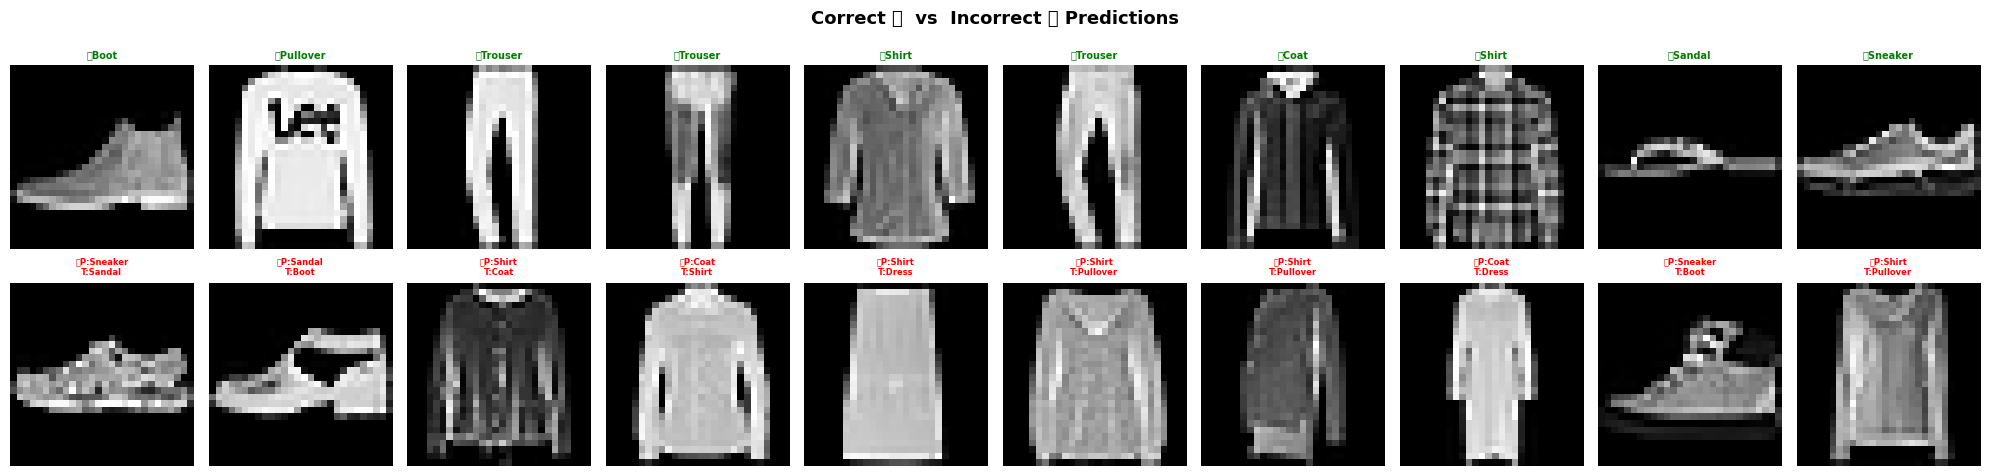

In [42]:
correct_idx   = np.where(y_pred == y_true)[0]
incorrect_idx = np.where(y_pred != y_true)[0]

fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Correct ✅  vs  Incorrect ❌ Predictions',
             fontsize=13, fontweight='bold')

for col in range(10):
    # Correct
    idx = correct_idx[col]
    axes[0][col].imshow(X_test[idx].reshape(28,28), cmap='gray')
    axes[0][col].set_title(f'✅{class_names[y_pred[idx]]}',
                            fontsize=7, color='green', fontweight='bold')
    axes[0][col].axis('off')

    # Incorrect
    idx2 = incorrect_idx[col]
    axes[1][col].imshow(X_test[idx2].reshape(28,28), cmap='gray')
    axes[1][col].set_title(
        f'❌P:{class_names[y_pred[idx2]]}\nT:{class_names[y_true[idx2]]}',
        fontsize=6, color='red', fontweight='bold')
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig('10_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

In [43]:
# 1. Keras format
best_model.save('fashion_cnn_model.keras')
print("✅ fashion_cnn_model.keras")

# 2. H5 format
best_model.save('fashion_cnn_model.h5')
print("✅ fashion_cnn_model.h5")

# 3. Weights only
best_model.save_weights('fashion_cnn_weights.weights.h5')
print("✅ fashion_cnn_weights.weights.h5")

# 4. Architecture JSON
with open('fashion_cnn_architecture.json', 'w') as f:
    f.write(best_model.to_json())
print("✅ fashion_cnn_architecture.json")

# 5. Model Info
info = {
    "model"        : "FashionMNIST_CNN",
    "dataset"      : "Fashion-MNIST",
    "date"         : datetime.now().strftime("%Y-%m-%d %H:%M"),
    "test_accuracy": round(float(test_acc), 4),
    "test_loss"    : round(float(test_loss), 4),
    "val_accuracy" : round(float(val_acc), 4),
    "total_params" : int(best_model.count_params()),
    "input_shape"  : [28, 28, 1],
    "num_classes"  : 10,
    "class_names"  : class_names
}
with open('model_info.json', 'w') as f:
    json.dump(info, f, indent=2)
print("✅ model_info.json")

print(f"\n📊 Final Test Accuracy : {test_acc*100:.2f}%")

✅ fashion_cnn_model.keras
✅ fashion_cnn_model.h5
✅ fashion_cnn_weights.weights.h5
✅ fashion_cnn_architecture.json
✅ model_info.json

📊 Final Test Accuracy : 91.70%


In [44]:
# All files to include
all_files = [
    'fashion_cnn_model.keras',
    'fashion_cnn_model.h5',
    'fashion_cnn_weights.weights.h5',
    'fashion_cnn_architecture.json',
    'model_info.json',
    '01_sample_images.png',
    '02_class_distribution.png',
    '03_pixel_distribution.png',
    '04_mean_images.png',
    '05_normalization.png',
    '06_augmentation.png',
    '07_training_history.png',
    '08_confusion_matrix.png',
    '09_accuracy_confidence.png',
    '10_predictions.png',
]

# Create ZIP
zip_name = 'fashion_cnn_complete.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in all_files:
        if os.path.exists(f):
            zf.write(f)
            print(f"   Added : {f}")

zip_mb = os.path.getsize(zip_name) / (1024*1024)
print(f"\n📦 ZIP Created : {zip_name}  ({zip_mb:.1f} MB)")

# ── Google Colab Download ──
try:
    from google.colab import files
    print("\n📥 Starting Colab Download...")
    files.download(zip_name)
    files.download('fashion_cnn_model.h5')
    print("✅ Download Started!")

# ── Local Jupyter ──
except ImportError:
    print("\n💡 Running Locally — Files saved in current folder:")
    for f in all_files:
        if os.path.exists(f):
            kb = os.path.getsize(f) / 1024
            print(f"   📄 {f:<45} ({kb:.0f} KB)")
    print(f"\n   📦 {zip_name}  ({zip_mb:.1f} MB)")

   Added : fashion_cnn_model.keras
   Added : fashion_cnn_model.h5
   Added : fashion_cnn_weights.weights.h5
   Added : fashion_cnn_architecture.json
   Added : model_info.json
   Added : 01_sample_images.png
   Added : 02_class_distribution.png
   Added : 03_pixel_distribution.png
   Added : 04_mean_images.png
   Added : 05_normalization.png
   Added : 06_augmentation.png
   Added : 07_training_history.png
   Added : 08_confusion_matrix.png
   Added : 09_accuracy_confidence.png
   Added : 10_predictions.png

📦 ZIP Created : fashion_cnn_complete.zip  (14.4 MB)

📥 Starting Colab Download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download Started!


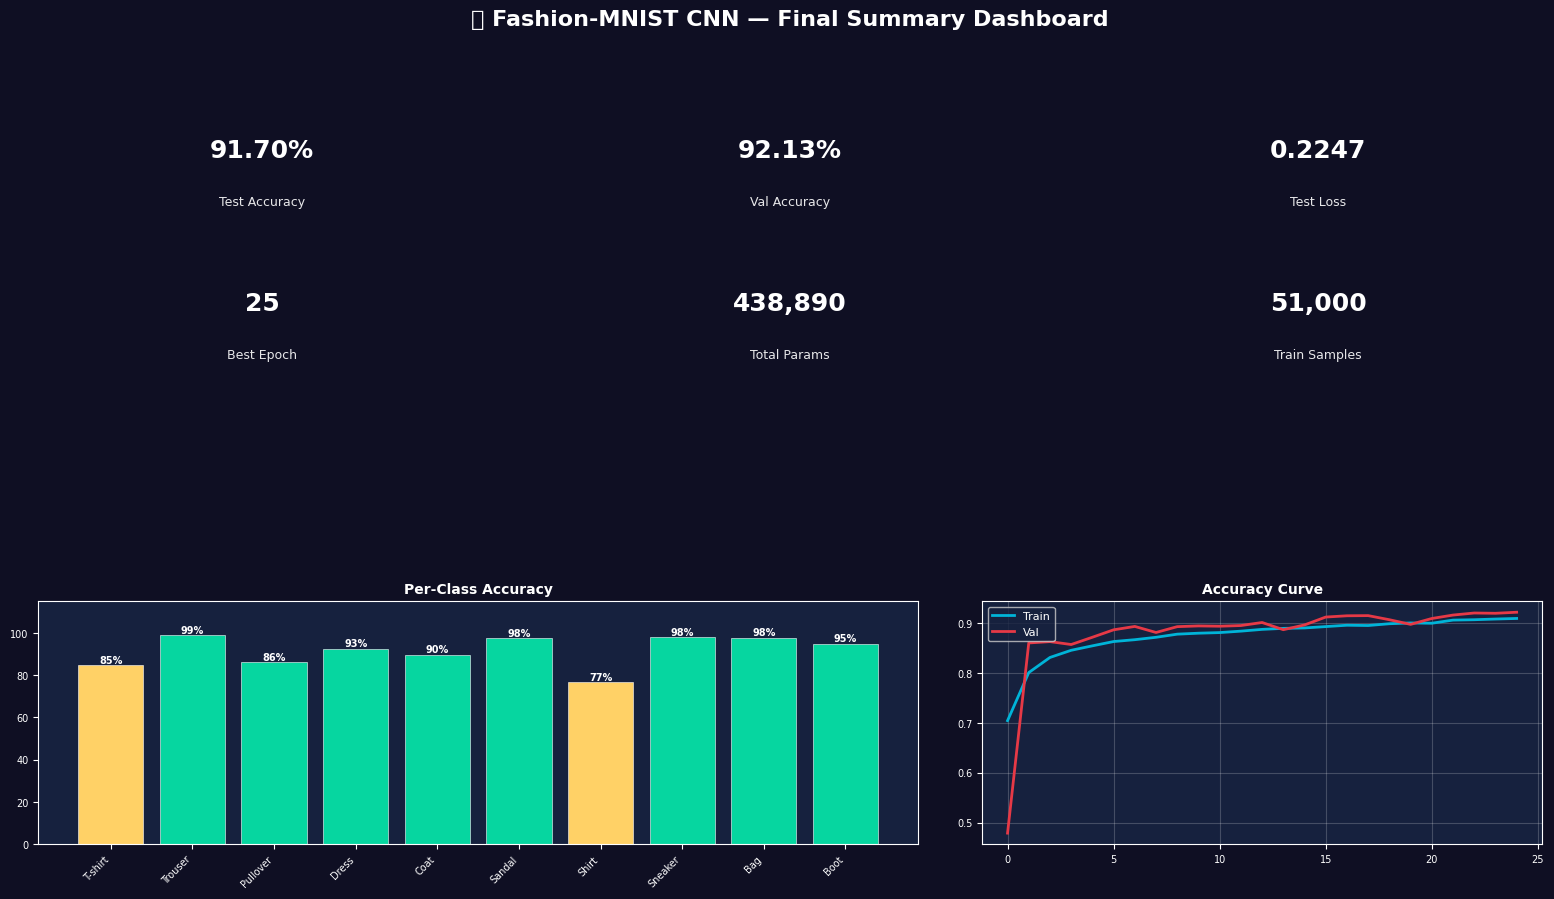

In [45]:
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#0f0f23')

# Title
fig.text(0.5, 0.96,
         '🏆 Fashion-MNIST CNN — Final Summary Dashboard',
         ha='center', fontsize=16, fontweight='bold', color='white')

# ── Metric Cards ──
metrics = [
    ('Test Accuracy',  f'{test_acc*100:.2f}%',         '#00b4d8'),
    ('Val Accuracy',   f'{val_acc*100:.2f}%',           '#06d6a0'),
    ('Test Loss',      f'{test_loss:.4f}',               '#e63946'),
    ('Best Epoch',     f'{best_ep}',                    '#ffd166'),
    ('Total Params',   f'{best_model.count_params():,}','#a8dadc'),
    ('Train Samples',  f'{X_train_f.shape[0]:,}',       '#f4a261'),
]

for i, (label, value, color) in enumerate(metrics):
    ax = fig.add_axes([0.03 + (i%3)*0.33, 0.74-(i//3)*0.17, 0.28, 0.13])
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            fontsize=18, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.18, label, ha='center', va='center',
            fontsize=9, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.axis('off')

# ── Per-Class Accuracy Bar ──
ax_bar = fig.add_axes([0.03, 0.05, 0.55, 0.27])
ax_bar.set_facecolor('#16213e')
bar_cols = ['#06d6a0' if a >= 0.85 else '#ffd166' if a >= 0.70
            else '#e63946' for a in per_class_acc]
bars = ax_bar.bar(class_names, per_class_acc*100,
                  color=bar_cols, edgecolor='white', lw=0.4)
for bar, acc in zip(bars, per_class_acc):
    ax_bar.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+1,
                f'{acc*100:.0f}%', ha='center',
                fontsize=7, color='white', fontweight='bold')
ax_bar.set_facecolor('#16213e')
ax_bar.set_ylim(0, 115)
ax_bar.set_title('Per-Class Accuracy', color='white',
                 fontsize=10, fontweight='bold')
ax_bar.tick_params(colors='white', labelsize=7)
ax_bar.set_xticklabels(class_names, rotation=45,
                        ha='right', color='white')
for sp in ax_bar.spines.values(): sp.set_color('white')

# ── Accuracy Curve ──
ax_line = fig.add_axes([0.62, 0.05, 0.35, 0.27])
ax_line.set_facecolor('#16213e')
ax_line.plot(history.history['accuracy'],
             color='#00b4d8', lw=2, label='Train')
ax_line.plot(history.history['val_accuracy'],
             color='#e63946', lw=2, label='Val')
ax_line.set_title('Accuracy Curve', color='white',
                  fontsize=10, fontweight='bold')
ax_line.tick_params(colors='white', labelsize=7)
ax_line.legend(fontsize=8, facecolor='#16213e', labelcolor='white')
ax_line.grid(alpha=0.2, color='white')
for sp in ax_line.spines.values(): sp.set_color('white')
ax_line.set_facecolor('#16213e')

plt.savefig('11_final_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f23')
plt.show()

In [46]:
# ── Final Print ──
print("\n" + "="*50)
print("  ✅ ALL DONE!")
print("="*50)
print(f"  Dataset      : Fashion-MNIST (70,000 images)")
print(f"  Classes      : {len(class_names)} clothing categories")
print(f"  Test Accuracy: {test_acc*100:.2f}%")
print(f"  Model Saved  : .keras | .h5 | weights | json")
print(f"  Charts Saved : 11 visualization files")
print("="*50)


  ✅ ALL DONE!
  Dataset      : Fashion-MNIST (70,000 images)
  Classes      : 10 clothing categories
  Test Accuracy: 91.70%
  Model Saved  : .keras | .h5 | weights | json
  Charts Saved : 11 visualization files
